# GPU vs CPU Monte Carlo Demo on Apple Silicon (Rescaled, Replications)

This notebook compares a simple Monte Carlo estimator implemented in two ways:

1. **CPU (NumPy, float64)** – baseline, traditional scientific computing.
2. **GPU (PyTorch on MPS, float32)** – uses the Apple Silicon GPU via the Metal backend.

We estimate
\begin{equation}
I_d = \mathbb{E}\left[ \frac{e^{-\tfrac12\lVert X \rVert^2}}{2^{-d/2}} \right], \quad X \sim \mathcal{N}(0, I_d),
\end{equation}
where the factor $2^{-d/2}$ is chosen so that
\begin{equation}
I_d \equiv 1 \quad \text{for all dimensions } d.
\end{equation}

Thus the **exact value is 1**, independent of `d`, which makes it easy to interpret absolute errors
as `|estimate − 1|`.

For each sample size `n` we run the experiment **multiple times** (replications) and record only
the **empirical errors** (no standard errors or confidence intervals).


## 1. Imports and device check

You need **PyTorch** installed with Apple Silicon / MPS support. If `torch.backends.mps.is_available()`
is `False`, the GPU run will fall back to CPU so you will not see a real GPU speed-up.


In [2]:
import time
import platform
import subprocess

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def _run_cmd(cmd):
    try:
        return subprocess.check_output(cmd, text=True)
    except Exception:
        return ""


def _get_mac_hardware_info():
    # Basic hardware (chip, cores, memory, model id)
    hw = _run_cmd(["system_profiler", "-detailLevel", "mini", "SPHardwareDataType"])

    info = {
        "chip": None,
        "cores": None,
        "memory": None,
        "model_id": None,
        "performance_cores": None,
        "efficiency_cores": None,
        "neural_engine_cores": None,
    }

    for line in hw.splitlines():
        line = line.strip()
        if line.startswith("Model Identifier:"):
            info["model_id"] = line.split(":", 1)[1].strip()
        elif line.startswith("Chip:") or line.startswith("Processor Name:"):
            info["chip"] = line.split(":", 1)[1].strip()
        elif line.startswith("Total Number of Cores:") or line.startswith("Number of Processors:"):
            info["cores"] = line.split(":", 1)[1].strip()
        elif line.startswith("Performance Cores:"):
            info["performance_cores"] = line.split(":", 1)[1].strip()
        elif line.startswith("Efficiency Cores:"):
            info["efficiency_cores"] = line.split(":", 1)[1].strip()
        elif line.startswith("Neural Engine Cores:"):
            info["neural_engine_cores"] = line.split(":", 1)[1].strip()
        elif line.startswith("Memory:"):
            info["memory"] = line.split(":", 1)[1].strip()

    # GPU info from Displays
    gpu_out = _run_cmd(["system_profiler", "-detailLevel", "mini", "SPDisplaysDataType"])
    gpus = []
    for line in gpu_out.splitlines():
        s = line.strip()
        if s.startswith("Chipset Model:") or s.startswith("Chipset:") or s.startswith("GPU:"):
            gpus.append(s.split(":", 1)[1].strip())

    info["gpus"] = gpus
    return info


def _memory_bandwidth_from_chip(chip: str | None) -> str | None:
    """
    Best-effort mapping from chip name to advertised unified memory bandwidth.
    Values are approximate and only filled in for common Apple Silicon chips.
    """
    if not chip:
        return None

    chip_lower = chip.lower()

    # Order matters: match more specific names first
    mapping = [
        ("m2 max", "400 GB/s"),
        ("m2 pro", "200 GB/s"),
        ("m2", "100 GB/s"),
        ("m1 max", "400 GB/s"),
        ("m1 pro", "200 GB/s"),
        ("m1", "68 GB/s"),
    ]

    for name, bw in mapping:
        if name in chip_lower:
            return bw

    return None


def _gpu_core_info_from_chip(chip: str | None) -> str | None:
    """
    Best-effort description of GPU core counts by chip family.
    We cannot see the exact config programmatically (e.g. 30 vs 38),
    so we report ranges where appropriate.
    """
    if not chip:
        return None

    s = chip.lower()
    if "m2 max" in s:
        return "30 or 38 GPU cores (depends on configuration; not distinguishable programmatically)"
    if "m2 pro" in s:
        return "16 or 19 GPU cores (varies by configuration)"
    if "m2" in s:
        return "up to 10 GPU cores (varies by configuration)"
    if "m1 max" in s:
        return "24 or 32 GPU cores (varies by configuration)"
    if "m1 pro" in s:
        return "14 or 16 GPU cores (varies by configuration)"
    if "m1" in s:
        return "7 or 8 GPU cores (varies by configuration)"
    return None


def _power_modes_from_pmset():
    """
    Inspect pmset to see Low Power / High Power modes where available.
    This is best-effort and may not report anything on some Macs.
    """
    out = _run_cmd(["pmset", "-g"])
    low_power = None
    high_power = None

    for line in out.splitlines():
        s = line.strip().lower()
        if s.startswith("lowpowermode"):
            try:
                low_power = int(s.split()[-1])
            except Exception:
                pass
        if "highpowermode" in s:
            try:
                high_power = int(s.split()[-1])
            except Exception:
                pass

    return low_power, high_power


def print_system_and_device_summary():
    # --- Python / library versions ---
    print("=== Python / Libraries ===")
    print(f"Python version : {platform.python_version()}")
    print(f"Platform       : {platform.platform()}")
    print(f"NumPy version  : {np.__version__}")
    try:
        print(f"PyTorch version: {torch.__version__}")
    except Exception:
        print("PyTorch version: <not available>")

    # --- Choose PyTorch device ---
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        device = torch.device("mps")
        backend_desc = "Apple Metal Performance Shaders (MPS, Apple GPU)"
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        backend_desc = "CUDA (discrete GPU)"
    else:
        device = torch.device("cpu")
        backend_desc = "CPU only (no GPU backend visible to PyTorch)"

    print(f"\nSelected device: {device}  [{backend_desc}]")

    # --- Mac hardware details ---
    info = _get_mac_hardware_info()

    print("\n=== Mac Hardware ===")
    if info["chip"]:
        print(f"Chip / CPU          : {info['chip']}")
    if info["cores"]:
        print(f"Total CPU cores     : {info['cores']}")
    if info["performance_cores"] or info["efficiency_cores"]:
        print(f"  - Performance cores: {info['performance_cores']}")
        print(f"  - Efficiency cores : {info['efficiency_cores']}")
    if info["memory"]:
        print(f"Unified memory      : {info['memory']}")
    if info["model_id"]:
        print(f"Model identifier    : {info['model_id']}")
    if info["neural_engine_cores"]:
        print(f"Neural Engine       : {info['neural_engine_cores']} cores")

    bw = _memory_bandwidth_from_chip(info["chip"])
    if bw:
        print(f"Memory bandwidth    : {bw} (from chip family, approximate)")
    else:
        print("Memory bandwidth    : not reliably detected from this system")

    gpu_core_info = _gpu_core_info_from_chip(info["chip"])
    if gpu_core_info:
        print(f"GPU core configuration: {gpu_core_info}")

    gpus = info.get("gpus") or []
    print(f"\nGPUs visible to macOS: {len(gpus)}")
    for g in gpus:
        print(f"  - {g}")

    # --- Power / performance mode (best effort) ---
    print("\n=== Power / Performance Mode (best-effort) ===")
    low_power, high_power = _power_modes_from_pmset()
    if low_power is not None:
        print(f"Low Power Mode      : {'ON' if low_power else 'OFF'}")
    else:
        print("Low Power Mode      : not reported by pmset")

    if high_power is not None:
        print(f"High Power Mode     : {'ON' if high_power else 'OFF'}")
    else:
        print("High Power Mode     : not reported (only on some models / OS versions)")

    return device


# ---- Run once at the top of the notebook ----
device = print_system_and_device_summary()

=== Python / Libraries ===
Python version : 3.12.11
Platform       : macOS-26.1-arm64-arm-64bit
NumPy version  : 2.3.2
PyTorch version: 2.8.0

Selected device: mps  [Apple Metal Performance Shaders (MPS, Apple GPU)]

=== Mac Hardware ===
Chip / CPU          : Apple M2 Max
Total CPU cores     : 12 (8 performance and 4 efficiency)
Unified memory      : 64 GB
Model identifier    : Mac14,5
Memory bandwidth    : 400 GB/s (from chip family, approximate)
GPU core configuration: 30 or 38 GPU cores (depends on configuration; not distinguishable programmatically)

GPUs visible to macOS: 1
  - Apple M2 Max

=== Power / Performance Mode (best-effort) ===
Low Power Mode      : OFF
High Power Mode     : not reported (only on some models / OS versions)


## 2. Monte Carlo estimators (rescaled so exact value is 1)

We implement the same Monte Carlo estimator twice:

- `mc_cpu_float64`: uses **NumPy** on CPU with `float64`.
- `mc_gpu_float32`: uses **PyTorch** on `device` (preferably MPS/GPU) with `float32`.

For each sample we compute
\begin{equation}
f(X) = \frac{e^{-\tfrac12\lVert X \rVert^2}}{2^{-d/2}},
\end{equation}
so that the exact expectation is 1 for all `d`.


In [3]:
def mc_cpu_float64(n: int, d: int) -> float:
    """Monte Carlo estimator on CPU using NumPy float64, rescaled so true value is 1."""
    # Normalization constant so that E[exp(-0.5||X||^2)/norm_const] = 1
    norm_const = (1 / np.sqrt(2.0)) ** d  # 2^(-d/2)
    x = np.random.normal(size=(n, d)).astype(np.float64)
    vals = np.exp(-0.5 * np.sum(x ** 2, axis=1)) / norm_const
    return float(vals.mean())


def mc_gpu_float32(n: int, d: int) -> float:
    """Monte Carlo estimator on GPU/CPU using PyTorch float32, rescaled so true value is 1.

    If `device` is a GPU backend ("mps" or "cuda"), this uses that device.
    """
    norm_const = (1.0 / np.sqrt(2.0)) ** d
    norm_const_t = torch.tensor(norm_const, device=device, dtype=torch.float32)

    x = torch.randn((n, d), device=device, dtype=torch.float32)
    vals = torch.exp(-0.5 * torch.sum(x ** 2, dim=1)) / norm_const_t
    return float(vals.mean().item())


def time_run(func, *args, sync_gpu: bool = False, **kwargs):
    """Utility to time a function call and return (value, elapsed_seconds).

    If `sync_gpu` is True and the global `device` is a GPU backend (MPS or CUDA),
    we synchronize before and after the call so that the timing reflects the
    actual wall-clock time of the GPU work (PyTorch GPU ops are asynchronous).
    """
    dev_type = getattr(device, "type", "").lower()

    if sync_gpu and dev_type in ("mps", "cuda"):
        if dev_type == "mps":
            torch.mps.synchronize()
        elif dev_type == "cuda":
            torch.cuda.synchronize()

    t0 = time.perf_counter()
    val = func(*args, **kwargs)

    if sync_gpu and dev_type in ("mps", "cuda"):
        if dev_type == "mps":
            torch.mps.synchronize()
        elif dev_type == "cuda":
            torch.cuda.synchronize()

    t1 = time.perf_counter()
    return val, t1 - t0


## 3. Parameters: dimension, sample sizes, and replications

- `d` – dimension of the normal vector.
- `ns` – list of sample sizes.
- `M` – number of **independent replications** per `(n, device)` combination.


In [4]:
d = 20                 # dimension of the normal vector
ns = [10_000, 100_000, 1_000_000]
M = 20                 # number of replications per n (change as desired)

exact_value = 1.0
print("Dimension d =", d)
print("Sample sizes n =", ns)
print("Number of replications M =", M)
print("Exact value (all d):", exact_value)


Dimension d = 20
Sample sizes n = [10000, 100000, 1000000]
Number of replications M = 20
Exact value (all d): 1.0


## 4. Run experiments with replications

For each `n` and each device (CPU / GPU) we perform `M` independent runs, and record:

- the estimate,
- the absolute error `|estimate − 1|`,
- the runtime.

We store all runs in a long-format DataFrame `df_runs`, and then compute summary statistics
by grouping over `(n, device)`.


In [5]:
records = []

for n in ns:
    for m in range(M):
        # CPU run
        val_cpu, t_cpu = time_run(mc_cpu_float64, n, d, sync_gpu=False)
        err_cpu = abs(val_cpu - exact_value)
        records.append(
            {
                "n": n,
                "rep": m,
                "device": "CPU",
                "value": val_cpu,
                "abs_error": err_cpu,
                "time_s": t_cpu,
            }
        )

        # GPU run
        val_gpu, t_gpu = time_run(mc_gpu_float32, n, d, sync_gpu=True)
        err_gpu = abs(val_gpu - exact_value)
        records.append(
            {
                "n": n,
                "rep": m,
                "device": "GPU",
                "value": val_gpu,
                "abs_error": err_gpu,
                "time_s": t_gpu,
            }
        )

df_runs = pd.DataFrame.from_records(records)
df_runs.head()


,n,rep,device,value,abs_error,time_s
0,10000,0,CPU,0.998521,0.001479,0.006181
1,10000,0,GPU,0.975212,0.024788,0.483549
2,10000,1,CPU,0.937145,0.062855,0.003521
3,10000,1,GPU,0.917333,0.082667,0.001329
4,10000,2,CPU,1.008204,0.008204,0.003346


### Summary table over replications

We summarize by `(n, device)` to get:

- average absolute error across replications,
- median, minimum, and maximum absolute error,
- average runtime,
- an average speed-up factor (CPU mean time / GPU mean time) for each `n`.


In [6]:
summary = (
    df_runs
    .groupby(["n", "device"], as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        min_abs_error=("abs_error", "min"),
        max_abs_error=("abs_error", "max"),
        mean_time_s=("time_s", "mean"),
    )
)

# Compute mean speed-up per n: CPU_mean_time / GPU_mean_time
speedup_records = []
for n in ns:
    row_cpu = summary[(summary["n"] == n) & (summary["device"] == "CPU")]
    row_gpu = summary[(summary["n"] == n) & (summary["device"] == "GPU")]
    if not row_cpu.empty and not row_gpu.empty:
        cpu_t = float(row_cpu["mean_time_s"].iloc[0])
        gpu_t = float(row_gpu["mean_time_s"].iloc[0])
        speedup = cpu_t / gpu_t if gpu_t > 0 else np.nan
        speedup_records.append({"n": n, "mean_speedup_CPU_over_GPU": speedup})

df_speedup = pd.DataFrame(speedup_records)
summary_merged = summary.merge(df_speedup, on="n", how="left")
summary_merged


,n,device,mean_abs_error,median_abs_error,min_abs_error,max_abs_error,mean_time_s,mean_speedup_CPU_over_GPU
0,10000,CPU,0.033057,0.033045,0.000010,0.124567,0.003369,0.133946
1,10000,GPU,0.028706,0.025828,0.000742,0.082667,0.025155,0.133946
2,100000,CPU,0.013582,0.014447,0.002115,0.029212,0.029701,5.680473
3,100000,GPU,0.010668,0.008136,0.001174,0.025151,0.005229,5.680473
4,1000000,CPU,0.003788,0.003097,0.000448,0.010079,0.310067,31.736138
5,1000000,GPU,0.002357,0.001455,0.000092,0.006624,0.009770,31.736138


## 5. Runtime comparison (mean over replications)

We plot the **mean runtime** for CPU and GPU at each `n`. This uses a linear vertical scale.


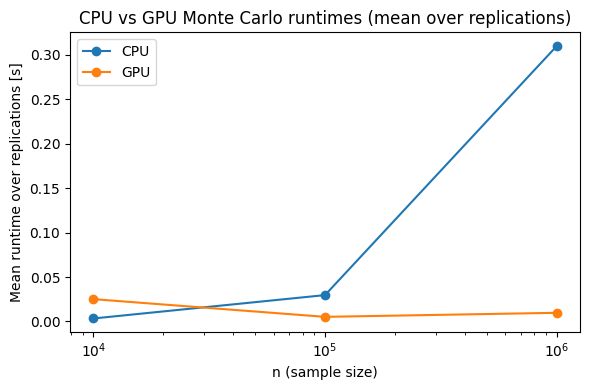

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

for device_name in ["CPU", "GPU"]:
    sub = summary[summary["device"] == device_name]
    ax.plot(sub["n"], sub["mean_time_s"], marker="o", label=device_name)

ax.set_xscale("log")
ax.set_xlabel("n (sample size)")
ax.set_ylabel("Mean runtime over replications [s]")
ax.set_title("CPU vs GPU Monte Carlo runtimes (mean over replications)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Error comparison on a log scale (empirical errors only)

We now compare **absolute errors** on a log scale. We do not compute standard errors or confidence
intervals; we only use empirical errors from the runs.

First we plot the **mean absolute error** over replications as a function of `n` for each device
on a log–log scale.


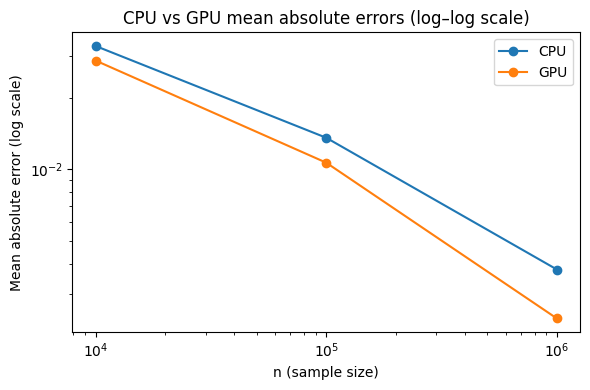

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

for device_name in ["CPU", "GPU"]:
    sub = summary[summary["device"] == device_name]
    ax.plot(sub["n"], sub["mean_abs_error"], marker="o", label=device_name)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (sample size)")
ax.set_ylabel("Mean absolute error (log scale)")
ax.set_title("CPU vs GPU mean absolute errors (log–log scale)")
ax.legend()
plt.tight_layout()
plt.show()


### Optional: scatter of individual absolute errors (log y-axis)

This plot shows all individual absolute errors for each `(n, device)` as jittered points on a
logarithmic vertical scale, to illustrate the spread of empirical errors across replications.


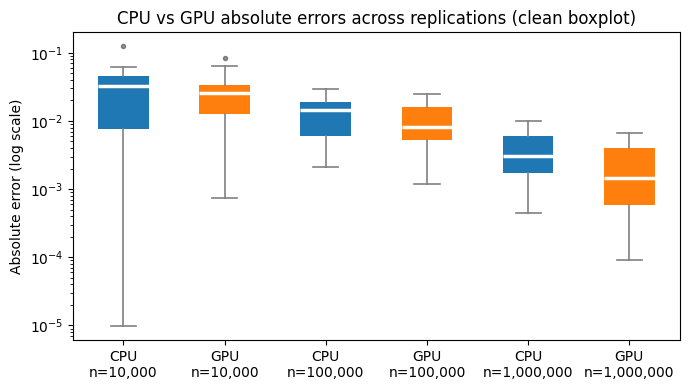

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

# Collect data CPU-n1, GPU-n1, CPU-n2, GPU-n2, ...
boxdata = []
labels = []

for n in ns:
    for device_name in ["CPU", "GPU"]:
        sub = df_runs[(df_runs["n"] == n) & (df_runs["device"] == device_name)]
        boxdata.append(sub["abs_error"].to_numpy())
        labels.append(f"{device_name}\nn={n:,}")

# Colors: CPU blue, GPU orange, repeating for each n
colors = ["tab:blue", "tab:orange"] * len(ns)

# Make boxplot with custom styling
bp = ax.boxplot(
    boxdata,
    patch_artist=True,
    tick_labels=labels,
    medianprops=dict(color="white", linewidth=2.5),   # make medians visible
    whiskerprops=dict(color="gray", linewidth=1.2),
    capprops=dict(color="gray", linewidth=1.2),
)

# Remove borders, set face colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_edgecolor("none")     # remove black border
    patch.set_facecolor(color)      # colored box

# Make medians match box color (more visible on colored box)
for median, color in zip(bp['medians'], colors):
    median.set_color("white")
    median.set_linewidth(2.5)

# Optional: reduce outlier marker size if desired
for flier in bp['fliers']:
    flier.set_marker('.')
    flier.set_markersize(6)
    flier.set_markerfacecolor("black")
    flier.set_alpha(0.4)

ax.set_yscale("log")
ax.set_ylabel("Absolute error (log scale)")
ax.set_title("CPU vs GPU absolute errors across replications (clean boxplot)")

plt.tight_layout()
plt.show()

## 7. Discussion

- The integral was rescaled so that the exact value is **1**, making absolute error easy to interpret.
- For each `n`, we ran `M` independent replications for CPU and GPU and looked only at **empirical**
  errors `|estimate − 1|` (no standard errors or confidence intervals).
- On an Apple Silicon MacBook Pro with MPS enabled, you should see:
  - The GPU achieving noticeably smaller **mean runtime** for large `n`.
  - CPU and GPU **mean absolute errors** of similar magnitude for each `n`.
  - The error decreasing roughly like $n^{-1/2}$ on the log–log plot.
- Any unusually small error at a given `n` and device is usually due to **Monte Carlo luck**, not
  a fundamental accuracy difference between float32 and float64 for this smooth problem.
